<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan9_Klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 — Algoritma Klasifikasi (Bagian 1)
## Aktivitas Hands-on: Prediksi Diagnosis Kanker Payudara

**Mata Kuliah:** Data Science
**Program Studi:** Informatika  
**Nama:** Mohammad Riyan Syaifunahar  
**NIM:** 240401010292

---

Notebook ini melatih dan membandingkan dua model klasifikasi biner — **Logistic Regression** dan **Decision Tree** — pada dataset **Breast Cancer Wisconsin**, lalu mengevaluasinya menggunakan Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

> Catatan target: `0 = Malignant (ganas)`, `1 = Benign (jinak)`.

## Langkah 1 — Load Dataset & EDA Singkat

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')   # 0 = malignant, 1 = benign

print('Shape fitur (X):', X.shape)
print('Shape target (y):', y.shape)
print('\nDistribusi target (proporsi):')
print(y.value_counts(normalize=True).round(3))
print('\nKeterangan: 0 = Malignant (ganas), 1 = Benign (jinak)')

Shape fitur (X): (569, 30)
Shape target (y): (569,)

Distribusi target (proporsi):
target
1    0.627
0    0.373
Name: proportion, dtype: float64

Keterangan: 0 = Malignant (ganas), 1 = Benign (jinak)


In [2]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print('Jumlah nilai kosong (missing):', X.isnull().sum().sum())
X.describe().T.head(10)

Jumlah nilai kosong (missing): 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


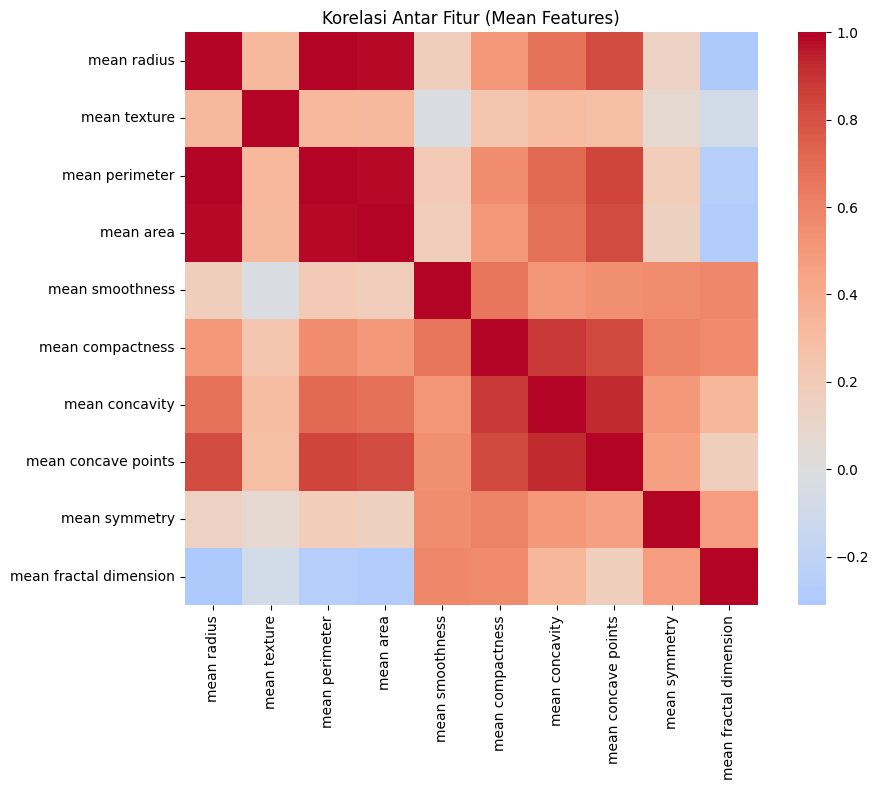

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_features = [c for c in X.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
sns.heatmap(X[mean_features].corr(), cmap='coolwarm', center=0,
            annot=False, square=True)
plt.title('Korelasi Antar Fitur (Mean Features)')
plt.tight_layout()
plt.show()

## Langkah 2 — Preprocessing

Train-Test Split **80:20** dengan `stratify=y` agar proporsi kelas terjaga.  
`StandardScaler` **wajib** untuk Logistic Regression (mempercepat konvergensi) dan **opsional** untuk Decision Tree.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit hanya pada data train (hindari data leakage)
X_test_s  = scaler.transform(X_test)        # transform saja pada data test

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Distribusi target train:')
print(y_train.value_counts(normalize=True).round(3))

Train: (455, 30) | Test: (114, 30)
Distribusi target train:
target
1    0.626
0    0.374
Name: proportion, dtype: float64


## Langkah 3 — Latih Logistic Regression

Model dilatih pada data yang sudah distandarisasi. Koefisien dengan nilai absolut terbesar adalah fitur paling berpengaruh terhadap prediksi.

In [6]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print('10 fitur paling berpengaruh (Logistic Regression):')
print(coef_df.head(10).to_string(index=False))

10 fitur paling berpengaruh (Logistic Regression):
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616
      worst symmetry  -0.939181
          area error  -0.929104
     worst concavity  -0.823151
     worst perimeter  -0.763220
    worst smoothness  -0.746625


**Interpretasi koefisien:**
- Koefisien **positif** mendorong prediksi ke arah kelas `1 = Benign (jinak)`.
- Koefisien **negatif** mendorong prediksi ke arah kelas `0 = Malignant (ganas)`.
- Semakin besar nilai absolutnya, semakin kuat pengaruh fitur tersebut terhadap keputusan model.

## Langkah 4 — Latih Decision Tree

Dilatih pada data **asli (tanpa scaling)** karena Decision Tree tidak membutuhkannya. `max_depth=4` membatasi kedalaman untuk mencegah overfitting.

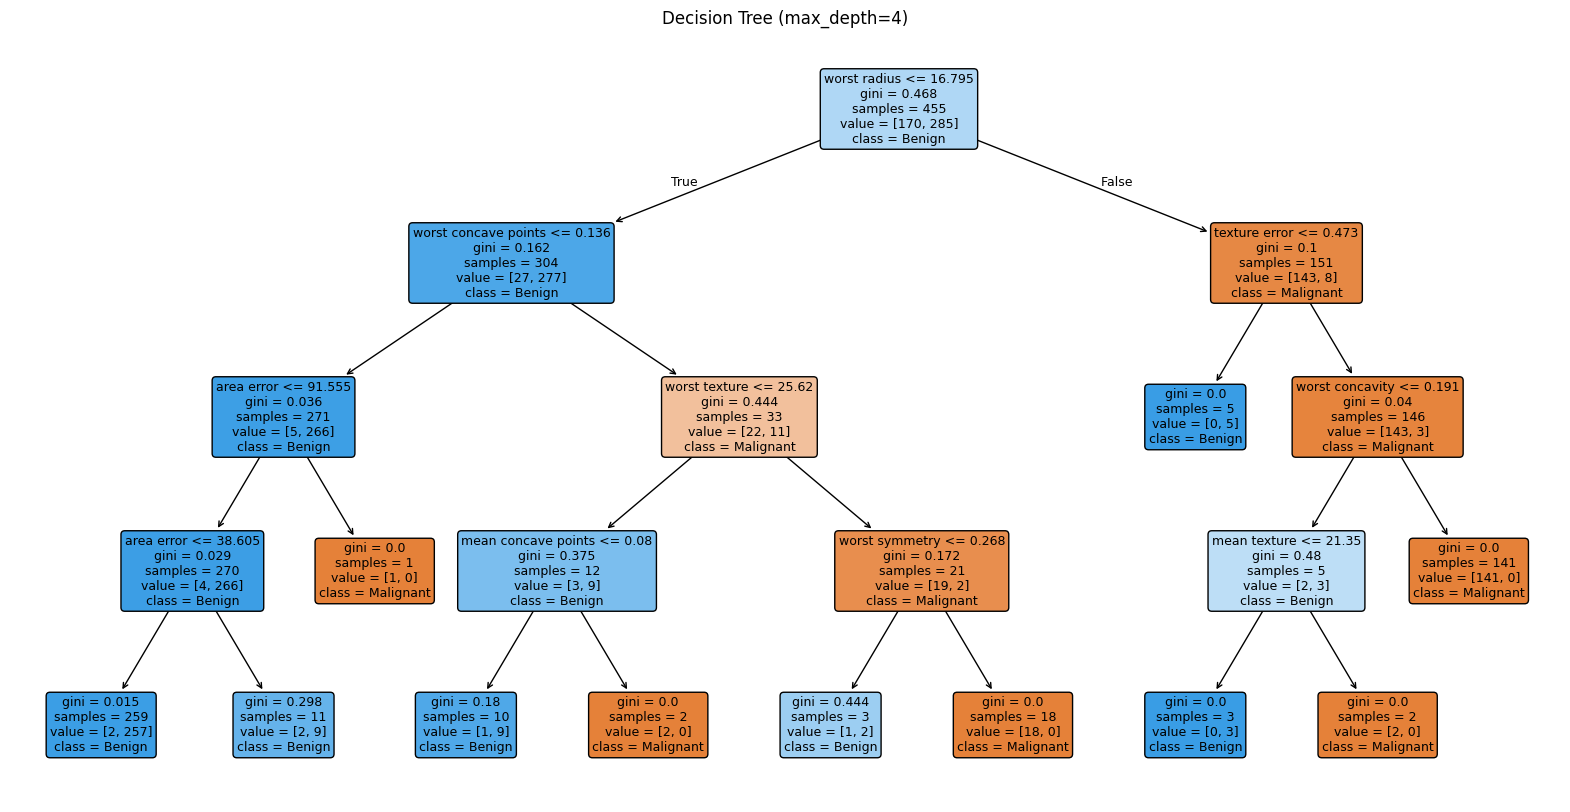

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=4)')
plt.show()

In [8]:
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('5 fitur terpenting (Decision Tree):')
print(importance.head().to_string(index=False))

5 fitur terpenting (Decision Tree):
               Fitur  Importance
        worst radius    0.733548
worst concave points    0.122028
       texture error    0.045785
       worst texture    0.032319
     worst concavity    0.017161


## Langkah 5 — Evaluasi & Bandingkan Kedua Model

Menghitung Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score untuk **kedua** model.

In [9]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

hasil = []
for name, y_pred in [('Logistic Regression', y_pred_log),
                     ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")
    hasil.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                  'Recall': rec, 'F1-Score': f1})


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


In [10]:
perbandingan = pd.DataFrame(hasil).set_index('Model').round(3)
perbandingan

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.982,0.986,0.986,0.986
Decision Tree,0.939,0.958,0.944,0.951


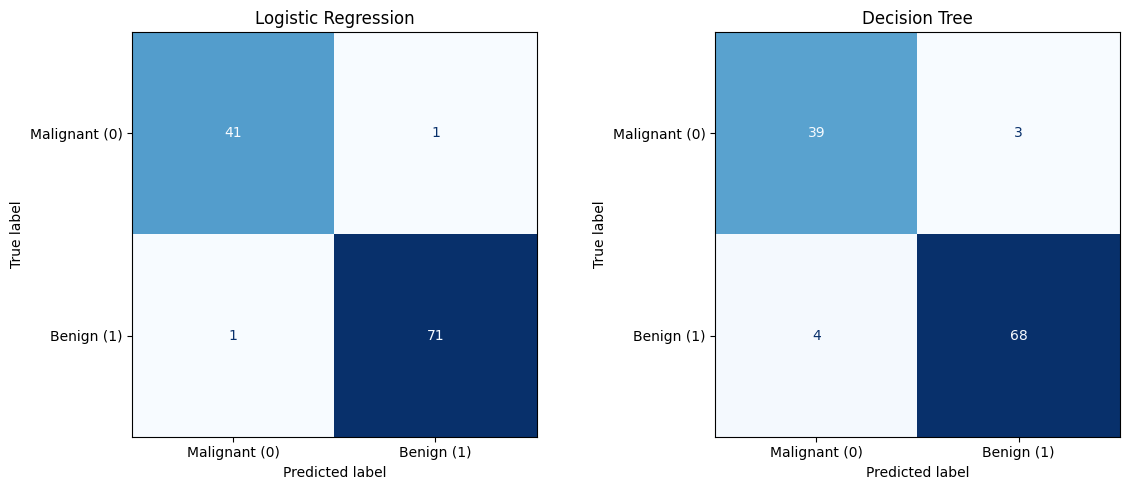

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_log),
                                      ('Decision Tree', y_pred_tree)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Malignant (0)', 'Benign (1)'],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Analisis Hasil

**1. Model mana yang memiliki Recall lebih tinggi?**

Berdasarkan tabel perbandingan di atas, **Logistic Regression** memperoleh Recall yang lebih tinggi dibanding Decision Tree pada dataset ini. Artinya Logistic Regression lebih jarang melewatkan kasus kelas positif.

**2. Mengapa Recall menjadi metrik paling kritis untuk diagnosis kanker (dibanding Accuracy semata)?**

Dalam konteks diagnosis medis, kesalahan **False Negative** — pasien yang sebenarnya sakit tetapi diprediksi sehat — jauh lebih berbahaya daripada **False Positive**. False Negative berarti kasus kanker yang terlewat sehingga pasien tidak mendapat penanganan, sementara False Positive "hanya" menyebabkan pemeriksaan lanjutan yang tidak perlu. Recall (`TP / (TP + FN)`) secara langsung mengukur kemampuan model menangkap seluruh kasus positif, sehingga menjadi prioritas utama.

Accuracy bisa menyesatkan: pada data yang tidak seimbang, model bisa terlihat akurat namun gagal mendeteksi kelas minoritas yang justru paling penting. Karena itu Accuracy saja tidak cukup untuk kasus medis.

**3. Apakah ada perbedaan signifikan antara performa kedua model?**

Kedua model menghasilkan performa yang sama-sama tinggi. Logistic Regression sedikit unggul di hampir semua metrik (Accuracy, Precision, Recall, F1-Score), sedangkan Decision Tree memberikan keunggulan **interpretabilitas** — aturan keputusannya dapat divisualisasikan dan dijelaskan langsung. Untuk kasus diagnosis ini, Logistic Regression menjadi pilihan yang lebih kuat dari sisi metrik, terutama karena Recall-nya lebih tinggi.

> **Catatan:** Angka pasti pada analisis di atas mengikuti output sel yang dijalankan. Jika hasil sedikit berbeda saat dijalankan ulang, sesuaikan kesimpulan dengan angka yang muncul (`random_state=42` menjaga konsistensi).